This notebook provides a first overview on the datasets we decided to utilize, focussing on Exploratory Data Analysis.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf

In [ ]:
# set visual style
plt.style.use('fivethirtyeight')
sns.set_context("notebook")

# loading helper
def load_and_preprocess(file, date_col=None):
    df = pd.read_csv(file)
    if date_col and date_col in df.columns:
        df[date_col] = pd.to_datetime(df[date_col])
    return df

# load datasets
data_folder = "../data/"
df_elec = load_and_preprocess(data_folder+'electricity.csv', 'date')
df_solar = load_and_preprocess(data_folder+'solar.csv', 'date')
df_traffic = load_and_preprocess(data_folder+'traffic.csv') # No date column in dataset, uses hours_from_start
df_vol = load_and_preprocess(data_folder+'volatility.csv', 'date')
df_wind = load_and_preprocess(data_folder+'wind.csv', 'date')

In [20]:
# list of datasets and their ID columns
datasets_info = [
    ('Electricity', df_elec, 'id'),
    ('Solar', df_solar, 'id'),
    ('Traffic', df_traffic, 'id'),
    ('Volatility', df_vol, 'Symbol'),
    ('Wind', df_wind, 'id')
]

summary_stats = []

for name, df, id_col in datasets_info:
    # count unique series
    num_series = df[id_col].nunique()
    
    #cCalculate lengths per series
    lengths = df.groupby(id_col).size()
    min_len = lengths.min()
    max_len = lengths.max()
    avg_len = lengths.mean()
    
    summary_stats.append({
        'Dataset': name,
        'No. of Series': num_series,
        'Min Length': min_len,
        'Max Length': max_len,
        'Avg Length': round(avg_len, 1),
        'Consistent Length': 'Yes' if min_len == max_len else 'No'
    })

# display as a clean DataFrame
df_summary = pd.DataFrame(summary_stats)
print("Time series length across datasets:\n"+df_summary.to_string(index=False))

Time series length across datasets:
    Dataset  No. of Series  Min Length  Max Length  Avg Length Consistent Length
Electricity            369        1248        6000      5956.8                No
      Solar            137       52560       52560     52560.0               Yes
    Traffic            963        4151        4151      4151.0               Yes
 Volatility             31        2194        5461      4898.5                No
       Wind             28       10957       10957     10957.0               Yes


---
## Electricity Dataset

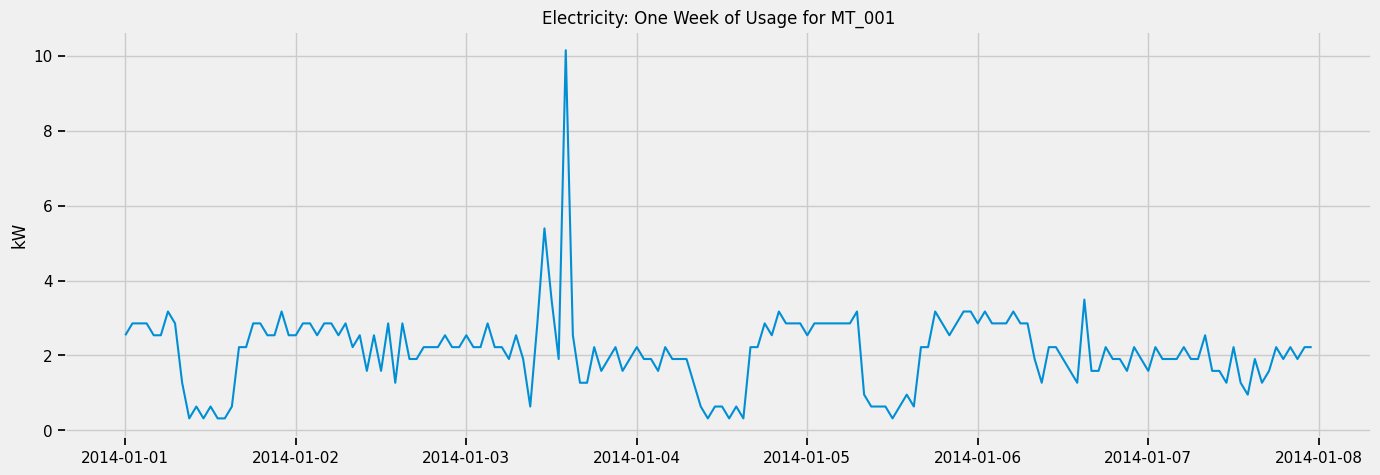

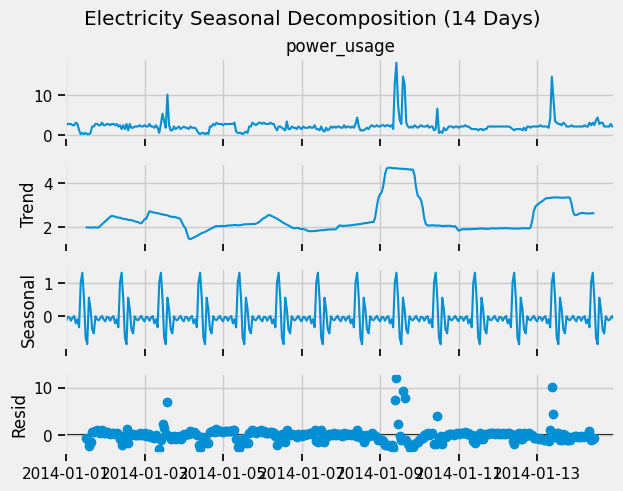

In [13]:
# select one client (e.g., MT_001)
client_id = 'MT_001'
elec_subset = df_elec[df_elec['id'] == client_id].sort_values('date').set_index('date')

# Plot 1: weekly view (168 hours)
plt.figure(figsize=(15, 5))
plt.plot(elec_subset['power_usage'][:168])
plt.title(f"Electricity: One Week of Usage for {client_id}")
plt.ylabel("kW")
plt.show()

# Plot 2: daily seasonality (Decomposition)
# period is 24 because data is hourly
res = seasonal_decompose(elec_subset['power_usage'].iloc[:24*14], period=24)
res.plot()
plt.suptitle("Electricity Seasonal Decomposition (14 Days)", y=1.02)
plt.show()

---
## Solar Dataset

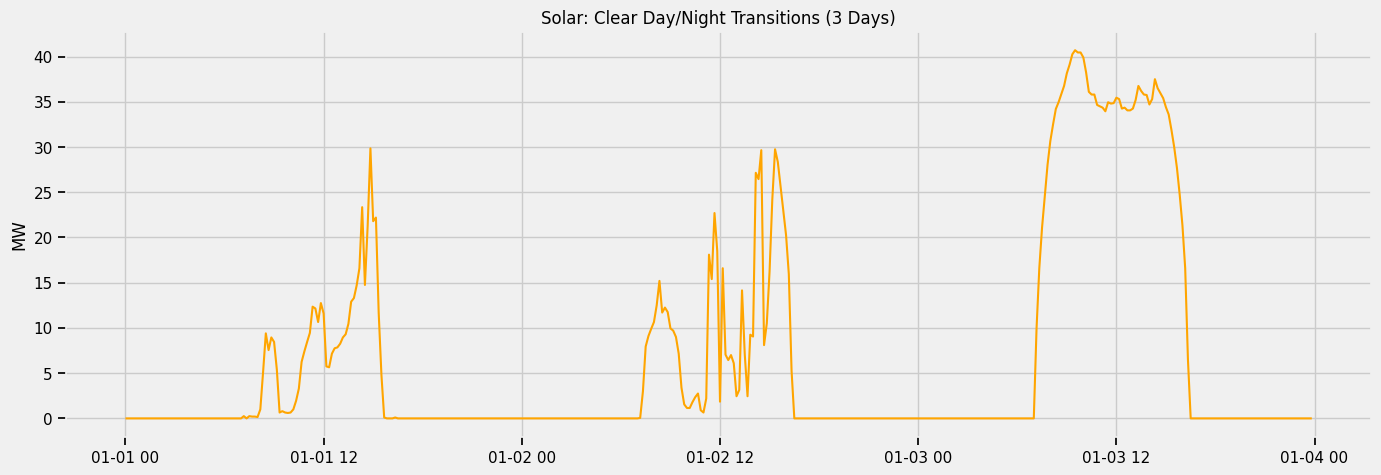

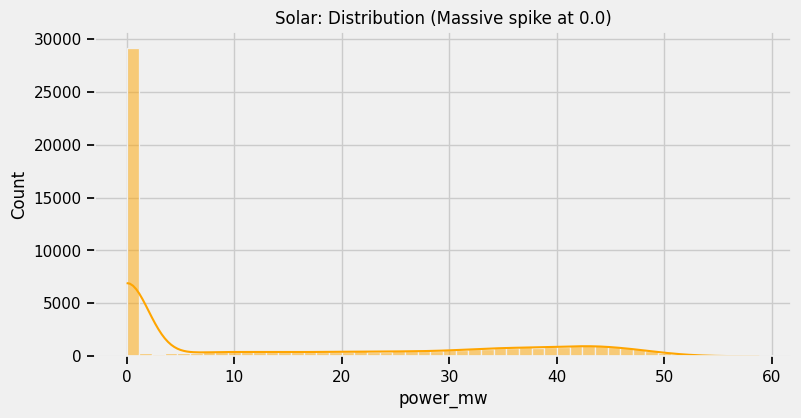

In [ ]:
# select one plant (id 0)
solar_subset = df_solar[df_solar['id'] == 0].sort_values('date').set_index('date')

# Plot 1: 3-day profile (showing nighttime zeros)
plt.figure(figsize=(15, 5))
plt.plot(solar_subset['power_mw'].iloc[:144*3], color='orange')
plt.title("Solar: Clear Day/Night Transitions (3 Days)")
plt.ylabel("MW")
plt.show()

# Plot 2: distribution of values (highly skewed due to night 0 values)
plt.figure(figsize=(8, 4))
sns.histplot(solar_subset['power_mw'], bins=50, color='orange', kde=True)
plt.title("Solar: Distribution (Massive spike at 0.0)")
plt.show()

---
## Traffic Dataset

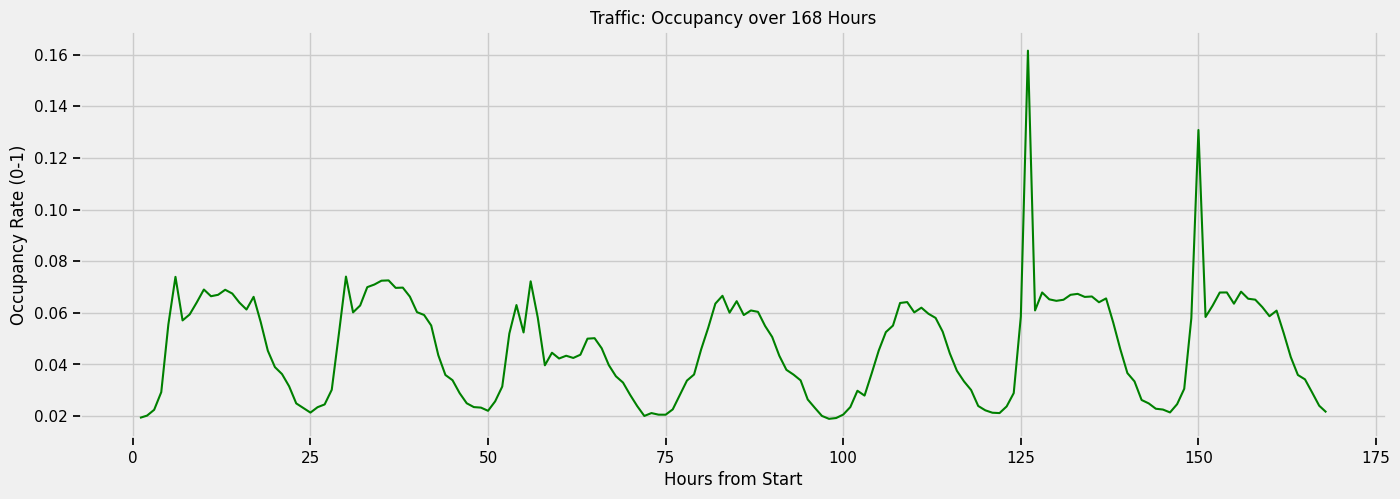

In [16]:
# select one sensor (id 400000)
traffic_subset = df_traffic[df_traffic['id'] == 400000].sort_values('hours_from_start')

plt.figure(figsize=(15, 5))
plt.plot(traffic_subset['hours_from_start'][:168], traffic_subset['occupancy'][:168], color='green')
plt.title("Traffic: Occupancy over 168 Hours")
plt.xlabel("Hours from Start")
plt.ylabel("Occupancy Rate (0-1)")
plt.show()

---
## Volatility Dataset

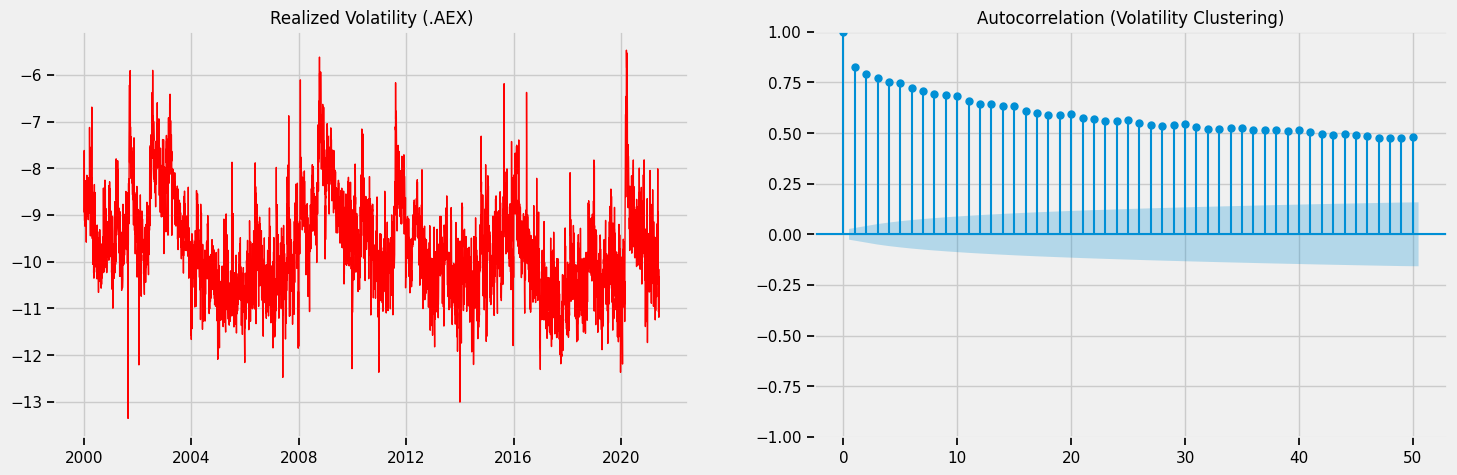

In [17]:
# select one index (e.g., .AEX)
vol_subset = df_vol[df_vol['Symbol'] == '.AEX'].sort_values('date').set_index('date')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: time series
ax1.plot(vol_subset['log_vol'], color='red', lw=1)
ax1.set_title("Realized Volatility (.AEX)")

# Plot 2: ACF (checks for persistence)
plot_acf(vol_subset['log_vol'].dropna(), lags=50, ax=ax2)
ax2.set_title("Autocorrelation (Volatility Clustering)")
plt.show()